In [48]:
from algs.cd_poly import CDPolynomial
import numpy as np
import matplotlib.pyplot as plt
from utils.misc import sample_ball_unif

Higher dimension or degree increase condition number. More samples descreases it.

In [49]:
dim = 10
d = 2
n = 10000

#x = sample_ball_unif(n_samples=n, rad=1, dim=dim)
x = np.random.uniform(low=-1, high=1, size=(n, dim))

p = CDPolynomial(x, degree=d, verbose=True)
print(p(x).mean(), p(x).max())

Data monomials shape: torch.Size([10000, 66])
Moment matrix cond num: 5.247013e+01
Empirical mean of CD poly: 66.0
66.0 288.1188


In [56]:
# how much more difficult does dimensionality make identifying an outlier with the CD poly?

from math import ceil

deg = 4
vals = np.zeros((deg, dim))
maxs = []

for d in range(1, deg+1):
    for i in range(1, dim+1):
        x = np.random.uniform(low=-1, high=1, size=(n, i))
        p = CDPolynomial(x, degree=d)
        maxs.append(p(x).max())
        pt = np.zeros((1, i))
        pt[0, 0] = 1 + 1e-1
        vals[d-1, i-1] = p(pt)[0] / p(x).mean()

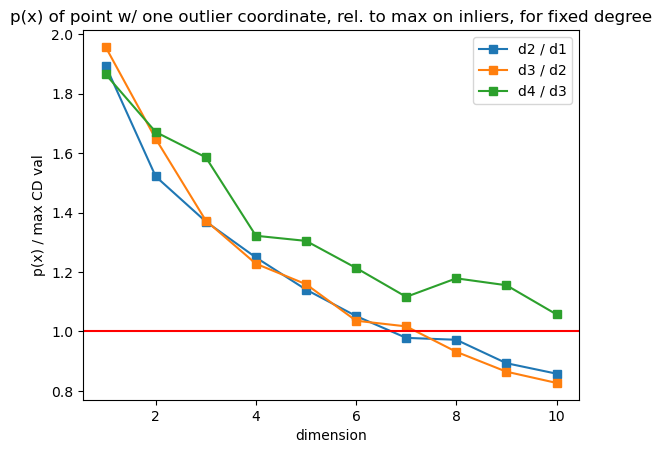

In [55]:
xs = [i for i in range(1,10+1)]

plt.plot(xs, vals[1] / vals[0], marker='s', label='d2 / d1')
plt.plot(xs, vals[2] / vals[1], marker='s', label='d3 / d2')
plt.plot(xs, vals[3] / vals[2], marker='s', label='d4 / d3')
#lt.plot([i for i in range(1,dim+1)], vals[3], marker='s', label='d=4')
plt.xlabel('dimension')
plt.ylabel('p(x) / max CD val')
plt.axhline(1, color='red')
plt.title('p(x) of point w/ one outlier coordinate, rel. to max on inliers, for fixed degree')
plt.legend()

In [37]:
# for every dimension, what's the least degree needed to identify the outlier?
dim = 7
n = 10_000
vals = np.zeros((deg, dim))

min_d = []
for i in range(1, dim+1):
    x = np.random.uniform(low=-1, high=1, size=(n, i))
    pt = np.zeros((1, i))
    pt[0, 0] = 1 + 1e-1

    for d in range(1, 10):
        p = CDPolynomial(x, degree=d)
        if p(pt)[0] > p(x).mean():
            min_d.append(d)
            break

In [38]:
min_d

[1, 1, 1, 2, 3, 5, 6]

Text(0.5, 1.0, 'min degree needed to identify outlier')

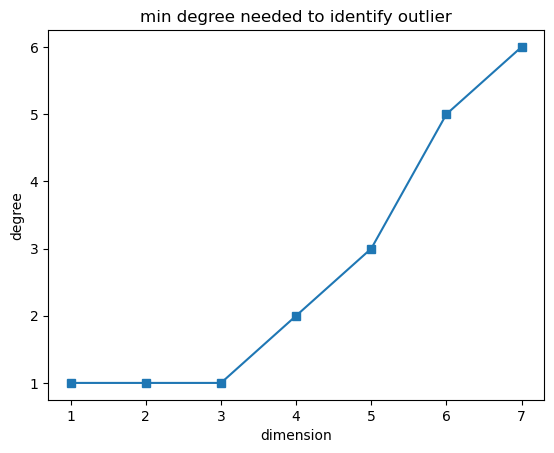

In [39]:
plt.plot(range(1,len(min_d)+1), min_d, 's-')
plt.xlabel('dimension')
plt.ylabel('degree')
plt.title('min degree needed to identify outlier')